In [1]:
import pandas as pd
import numpy as np
import re
import pymorphy3
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import LinearSVC

In [3]:
path = "C:/Users/igrew/OneDrive/Desktop/Course Work/Datasets/theme_detector/ua_news_test_theme.csv"
df = pd.read_csv(path)
df = df.dropna()
print(f"Завантажено {len(df)} записів")
df.head()

Завантажено 50000 записів


,title,text,tags,target
0,Бійка на Драгобраті: нардепи взяли на поруки ...,Про це повідомляє Еспресо.TV з посиланням на п...,|Правий сектор|поруки|Новини|бійка|Драгобрат|,політика
1,ЯСТРЕМСЬКА: «Не вдалося добре виспатися перед ...,Українська тенісистка Даяна Ястремська розпові...,Теніс|Wta|Вероніка Кудерметова|Даяна Ястремськ...,спорт
2,Джеймі Малларкі – Хама Ворті. Відео нокауту,В ніч з 27 на 28 березня в Лас-Вегасі проходит...,Mma|Ufc|Ufc 260|Джеймі Малларкі|Хама Ворті|від...,спорт
3,Дівчина закохалася в ляльку-зомбі і планує з ...,Про це пише видання Metro. Дівчина продемонстр...,|психологія|курйози|треш|Новини|кохання|,новини
4,"Клінтон стверджує, що Трамп збрехав майже 60 ...","Про це вона написала в Twitter. ""Дональд Трамп...",|США|Дональд Трамп|дебати|Новини|Гілларі Клінтон|,політика


In [4]:
print("Unique targets:")
print(df['target'].unique())
print("\nValue counts:")
print(df['target'].value_counts())
print(f"\nNumber of nans: {df['target'].isnull().sum().sum()}")

Unique targets:
['політика' 'спорт' 'новини' 'технології' 'бізнес']

Value counts:
target
політика      10000
спорт         10000
новини        10000
технології    10000
бізнес        10000
Name: count, dtype: int64

Number of nans: 0


In [5]:
all_text = (
    df['title'].fillna('') + ' ' +
    df['text'].fillna('') + ' ' +
    df['tags'].fillna('').str.replace('|', ' ', regex=False)
)
all_text = all_text.to_frame(name='all_text')
all_text

,all_text
0,Бійка на Драгобраті: нардепи взяли на поруки ...
1,ЯСТРЕМСЬКА: «Не вдалося добре виспатися перед ...
2,Джеймі Малларкі – Хама Ворті. Відео нокауту В ...
3,Дівчина закохалася в ляльку-зомбі і планує з ...
4,"Клінтон стверджує, що Трамп збрехав майже 60 ..."
...,...
49995,В авіакатастрофі американського літака-розвід...
49996,У новому світлі. Астрономи отримали незвичайні...
49997,Терористи ІДІЛ викрали в Сирії щонайменше 400...
49998,ЧС-2021 з біатлону. Жіноча естафета. Текстова ...


In [6]:
with open('../stopwords_ua.txt', 'r', encoding='utf-8') as f:
    content = f.read()
    stopwords = content.split()
print(stopwords[:150])

['а', 'аби', 'абиде', 'абиким', 'абикого', 'абиколи', 'абикому', 'абикуди', 'абихто', 'абичий', 'абичийого', 'абичийому', 'абичим', 'абичию', 'абичия', 'абичиє', 'абичиєму', 'абичиєю', 'абичиєї', 'абичиї', 'абичиїй', 'абичиїм', 'абичиїми', 'абичиїх', 'абичого', 'абичому', 'абищо', 'абияка', 'абияке', 'абиякий', 'абияким', 'абиякими', 'абияких', 'абиякого', 'абиякому', 'абиякою', 'абиякої', 'абияку', 'абиякі', 'абиякій', 'абиякім', 'або', 'абощо', 'авжеж', 'авось', 'ага', 'ад', 'адже', 'аж', 'ажень', 'аз', 'ай', 'але', 'ало', 'амінь', 'ант', 'ану', 'ані', 'аніде', 'аніж', 'анізащо', 'аніким', 'анікого', 'анікогісінько', 'аніколи', 'анікому', 'аніскільки', 'аніхто', 'анічим', 'анічого', 'анічогісінько', 'анічому', 'аніщо', 'аніяка', 'аніяке', 'аніякий', 'аніяким', 'аніякими', 'аніяких', 'аніякого', 'аніякому', 'аніякою', 'аніякої', 'аніяку', 'аніякі', 'аніякій', 'аніякім', 'аніякісенька', 'аніякісеньке', 'аніякісенький', 'аніякісеньким', 'аніякісенькими', 'аніякісеньких', 'аніякісенького

In [7]:
tqdm.pandas()

In [8]:
def filtering(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r'[^\w\s]', '', sentence)
    words = sentence.split()
    clean_text = [word for word in words if word not in stopwords]
    return ' '.join(clean_text)

all_text['all_text'] = all_text['all_text'].progress_apply(filtering)
all_text

100%|██████████| 50000/50000 [01:49<00:00, 455.27it/s]


,all_text
0,бійка драгобраті нардепи взяли поруки бійців п...
1,ястремська вдалося виспатися матчем пен шуай у...
2,джеймі малларкі хама ворті відео нокауту ніч 2...
3,дівчина закохалася лялькузомбі планує весілля ...
4,клінтон стверджує трамп збрехав 60 разів дебат...
...,...
49995,авіакатастрофі американського літакарозвідника...
49996,новому світлі астрономи отримали незвичайні зо...
49997,терористи іділ викрали сирії щонайменше 400 лю...
49998,чс2021 біатлону жіноча естафета текстова транс...


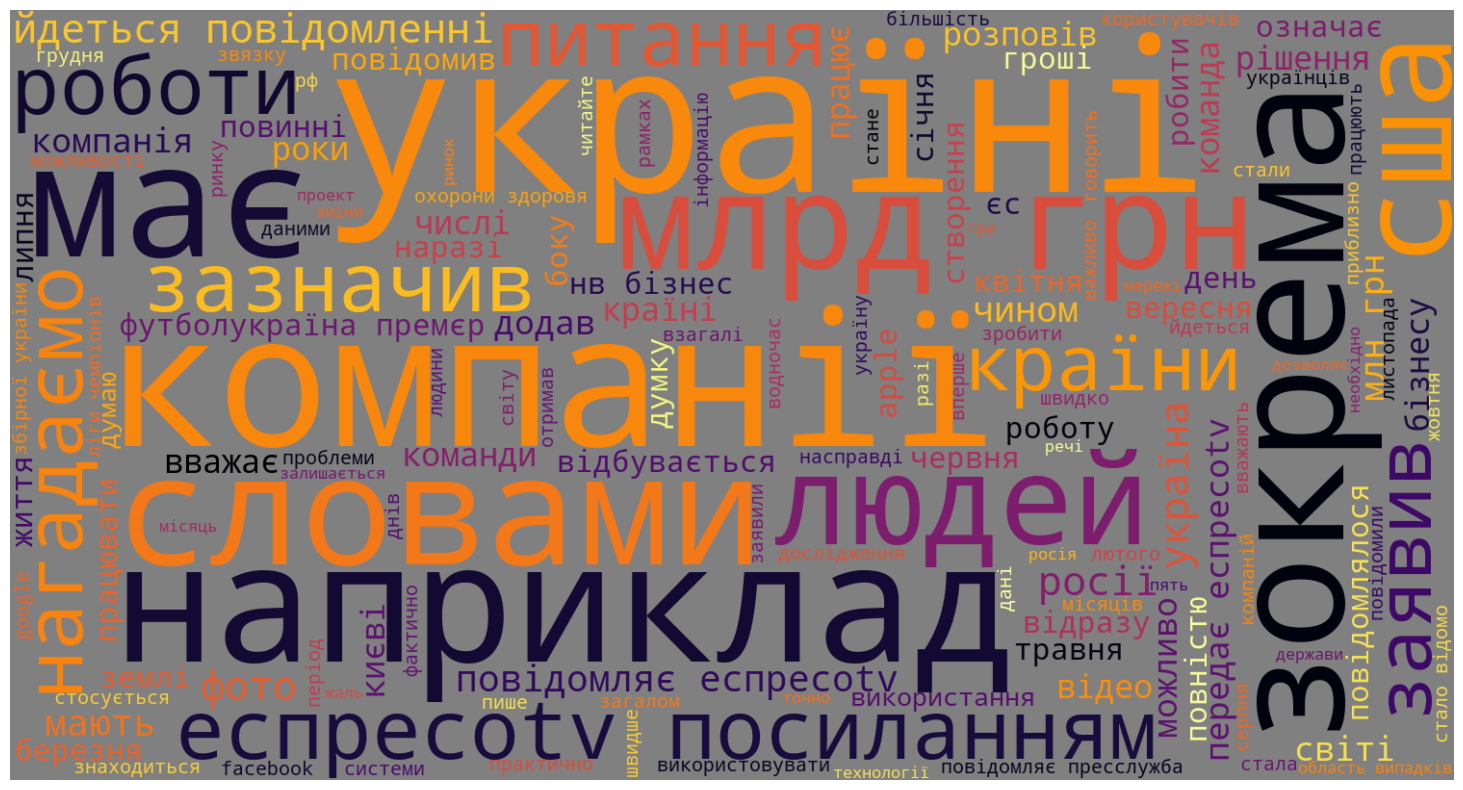

In [15]:
text_for_wc = ' '.join(all_text['all_text'])
wordcloud = WordCloud(
    height=800,
    width=1500,
    prefer_horizontal=0.6,
    min_font_size=10,
    max_font_size=220,
    random_state=42,
    colormap='inferno',
    background_color='grey',
    max_words=150
).generate(text_for_wc)

plt.figure(figsize=(15,8))
plt.axis(False)
plt.imshow(wordcloud, interpolation='bilinear')
plt.tight_layout()
plt.show()

In [9]:
morph = pymorphy3.MorphAnalyzer(lang='uk')

lemma_cache = {}

def lemmatize_text(sentence):
    words = sentence.split()
    lemmas = []
    for word in words:
        if word not in lemma_cache:
            lemma_cache[word] = morph.parse(word)[0].normal_form
        lemmas.append(lemma_cache[word])
    return ' '.join(lemmas)

all_text['all_text'] = all_text['all_text'].progress_apply(lemmatize_text)
print(f"Кешовано {len(lemma_cache)} унікальних слів")
all_text

100%|██████████| 50000/50000 [00:33<00:00, 1489.88it/s]

Кешовано 455481 унікальних слів


,all_text
0,бійка драгобрат нардеп взяти порука боєць пс п...
1,ястремська вдатися виспатися матч пен шуай укр...
2,джеймі малларкий хам ворт відео нокаут ніч 27 ...
3,дівчина закохатися лялькузомбі планувати весіл...
4,клінтон стверджувати трамп збрехати 60 раз деб...
...,...
49995,авіакатастрофа американський літакарозвідник з...
49996,нове світлий астроном отримати незвичайний зоб...
49997,терорист іділ викрасти сирія щонайменше 400 лю...
49998,чс2021 біатлон жіночий естафета текстовий тран...


In [10]:
X = all_text['all_text'].values
Y = df['target'].values
print(f"X: {X[:2]}")
print(f"Y: {Y[:2]}")
print(f"X shape: {X.shape}")
print(f"Y shape {Y.shape}")

X: ['бійка драгобрат нардеп взяти порука боєць пс повідомляти еспресоtv посилання пресслужба правий сектор суд відпустити боєць пс порука народний депутат народний фронт володимир соляра юрій тимошенко бажання взяти порука арештований боєць виявляти представник свобода парламент олег осуховський юрій левченко андрій іллєнко батьківщина ігор луценко позафракційний володимир парасюк поліція повідомити територія туристичний невідомий чоловік камуфльований одяг вчинити бійка обслуговуючий персонал застосування зброя згодом зявитися інформація боєць правий сектор учасник сутичка драгобрат загрожувати три сема грати згодом апеляційний суд закарпатський область звільнити боєць правий сектор антон окороковий відпустити порука депутат народний фронт юрій тимошенко батьківщина ігор луценко колегія суддів апеляційний суд закарпатський область ухвалити рішення випустити драгобратський боєць сергій тищенко прізвисько нацик порука народний депутат правий сектор порука новина бійка драгобрат'
 'ястре

In [11]:
vectorizer = TfidfVectorizer(
    max_features=30000,  
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,  
    use_idf=True,
    smooth_idf=True
)

X = vectorizer.fit_transform(X)
print(f"TF-IDF векторизація завершена: {X.shape[1]} ознак")

TF-IDF векторизація завершена: 30000 ознак


In [12]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5635964 stored elements and shape (50000, 30000)>
  Coords	Values
  (0, 4715)	0.19790490855012186
  (0, 16298)	0.07294526189195706
  (0, 5280)	0.09218611683592091
  (0, 20253)	0.3107248551363368
  (0, 4449)	0.20729791724757832
  (0, 21839)	0.2042326755095452
  (0, 19560)	0.030681676622503564
  (0, 9816)	0.041913486477599786
  (0, 20318)	0.044437957584281484
  (0, 20922)	0.050731690337553155
  (0, 20665)	0.18605089138769482
  (0, 24040)	0.1568778218591499
  (0, 25583)	0.11098435428488841
  (0, 6876)	0.1500817486841966
  (0, 16316)	0.15271623630621095
  (0, 8324)	0.12203134489749547
  (0, 27939)	0.1305829324569425
  (0, 6220)	0.08621198383500382
  (0, 29302)	0.13377286082060685
  (0, 26332)	0.15951522543082503
  (0, 3950)	0.06863597643373165
  (0, 3734)	0.10279770392071096
  (0, 5996)	0.08350060079088643
  (0, 20815)	0.047825963145535305
  (0, 23891)	0.06633434991873663
  :	:
  (49999, 22177)	0.11505091078084653
  (49999, 2897

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

In [22]:
# model1 = LogisticRegression(
#     class_weight='balanced', 
#     random_state=42,
#     max_iter=1000,
#     )

In [14]:
# model_theme = LinearSVC(
#     C=0.5,  
#     loss='squared_hinge',  
#     class_weight='balanced', 
#     max_iter=3000,  
#     random_state=42,
#     dual=False, 
#     verbose=1  
# )
# print("Модель створено з оптимізованими параметрами")
from sklearn.calibration import CalibratedClassifierCV

svc = LinearSVC(
    C=0.5,
    loss='squared_hinge',
    max_iter=3000,
    dual=False,
    verbose=1
)

model_theme = CalibratedClassifierCV(svc, cv=3)
print("Модель створено")

Модель створено


In [15]:
model_theme.fit(X_train, Y_train)

[LibLinear][LibLinear][LibLinear]

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","LinearSVC(C=0...00, verbose=1)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" o

In [16]:
X_train_pred = model_theme.predict(X_train)
accuracy_train = accuracy_score(X_train_pred, Y_train)
print(f"Accuracy score of the training data: {accuracy_train * 100:.2f}%")

Accuracy score of the training data: 98.49%


In [17]:
X_test_pred = model_theme.predict(X_test)
accuracy_test = accuracy_score(X_test_pred, Y_test)
print(f"Accuracy score of the test data: {accuracy_test * 100:.2f}%")

Accuracy score of the test data: 94.18%


In [18]:
print("\t\t\tCLASSIFICATION REPORT")
print(classification_report(
    Y_test,
    X_test_pred,
    digits=4 
))

			CLASSIFICATION REPORT
              precision    recall  f1-score   support

      бізнес     0.9264    0.9570    0.9415      2000
      новини     0.9177    0.8865    0.9018      2000
    політика     0.9150    0.9095    0.9122      2000
       спорт     0.9910    0.9965    0.9938      2000
  технології     0.9581    0.9595    0.9588      2000

    accuracy                         0.9418     10000
   macro avg     0.9416    0.9418    0.9416     10000
weighted avg     0.9416    0.9418    0.9416     10000




Кількість класів (тем): 5
Теми: ['бізнес', 'новини', 'політика', 'спорт', 'технології']


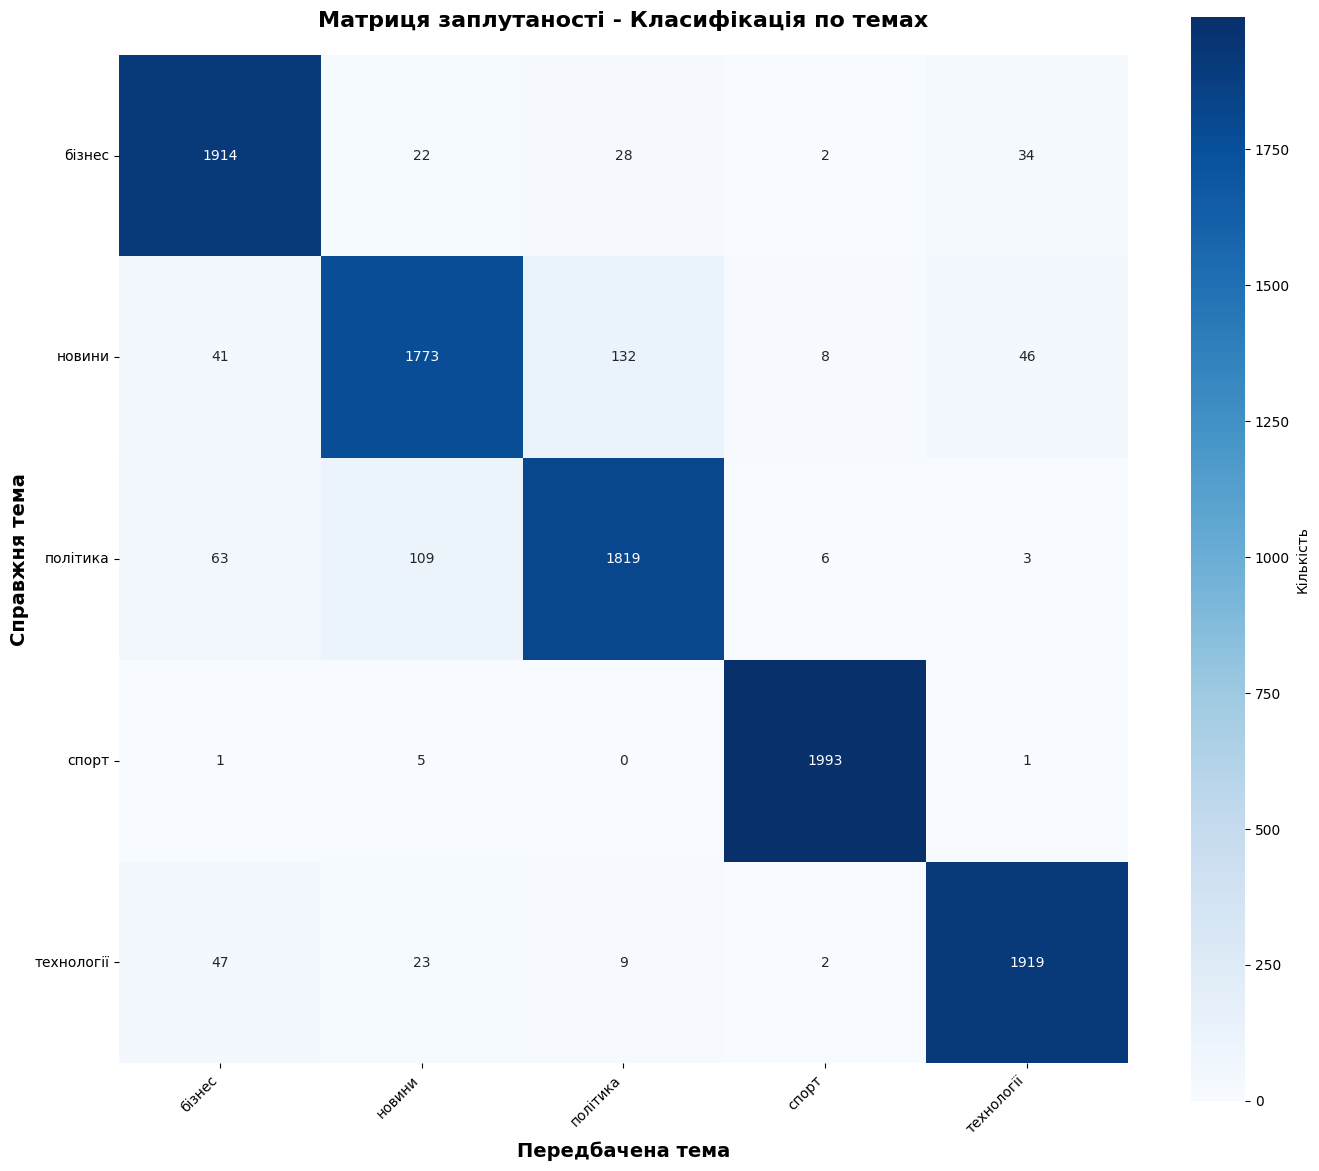


ДЕТАЛЬНА СТАТИСТИКА ПО КОЖНІЙ ТЕМІ
бізнес               | Правильно: 1914 / 2000 | Точність: 95.70%
новини               | Правильно: 1773 / 2000 | Точність: 88.65%
політика             | Правильно: 1819 / 2000 | Точність: 90.95%
спорт                | Правильно: 1993 / 2000 | Точність: 99.65%
технології           | Правильно: 1919 / 2000 | Точність: 95.95%


In [19]:
cm = confusion_matrix(Y_test, X_test_pred)

unique_classes = sorted(np.unique(Y))
print(f"\nКількість класів (тем): {len(unique_classes)}")
print(f"Теми: {unique_classes}")

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=unique_classes,
    yticklabels=unique_classes,
    cbar_kws={'label': 'Кількість'},
    square=True
)
plt.title('Матриця заплутаності - Класифікація по темах', fontsize=16, weight='bold', pad=20)
plt.ylabel('Справжня тема', fontsize=14, weight='bold')
plt.xlabel('Передбачена тема', fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ДЕТАЛЬНА СТАТИСТИКА ПО КОЖНІЙ ТЕМІ")
print("="*70)
for i, theme in enumerate(unique_classes):
    correct = cm[i][i]
    total = cm[i].sum()
    accuracy = correct / total * 100 if total > 0 else 0
    print(f"{theme:20} | Правильно: {correct:4} / {total:4} | Точність: {accuracy:.2f}%")
print("="*70)

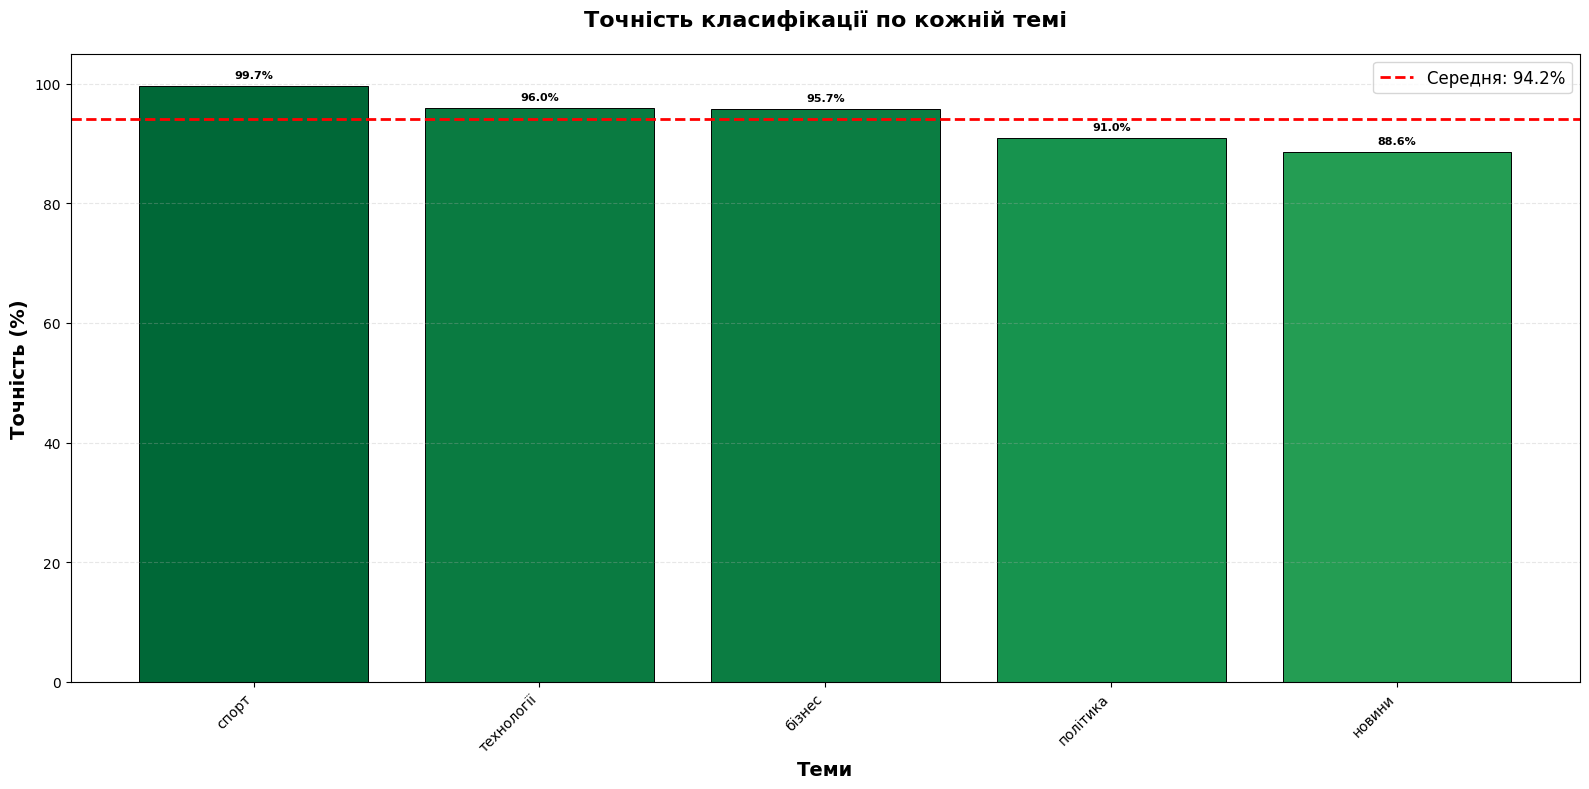

Середня точність по всіх темах: 94.18%


In [20]:
theme_accuracies = []
for i, theme in enumerate(unique_classes):
    correct = cm[i][i]
    total = cm[i].sum()
    accuracy = correct / total * 100 if total > 0 else 0
    theme_accuracies.append({'Theme': theme, 'Accuracy': accuracy, 'Total': total})

df_accuracies = pd.DataFrame(theme_accuracies)
df_accuracies = df_accuracies.sort_values('Accuracy', ascending=False)

plt.figure(figsize=(16, 8))
colors = plt.cm.RdYlGn(df_accuracies['Accuracy'] / 100)
bars = plt.bar(range(len(df_accuracies)), df_accuracies['Accuracy'], color=colors, edgecolor='black', linewidth=0.7)
plt.xlabel('Теми', fontsize=14, weight='bold')
plt.ylabel('Точність (%)', fontsize=14, weight='bold')
plt.title('Точність класифікації по кожній темі', fontsize=16, weight='bold', pad=20)
plt.xticks(range(len(df_accuracies)), df_accuracies['Theme'], rotation=45, ha='right', fontsize=10)
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3, linestyle='--')

avg_accuracy = df_accuracies['Accuracy'].mean()
plt.axhline(y=avg_accuracy, color='red', linestyle='--', linewidth=2, label=f'Середня: {avg_accuracy:.1f}%')
plt.legend(fontsize=12)

for i, (idx, row) in enumerate(df_accuracies.iterrows()):
    plt.text(i, row['Accuracy'] + 1, f"{row['Accuracy']:.1f}%", 
             ha='center', va='bottom', fontsize=8, weight='bold')

plt.tight_layout()
plt.show()

print(f"Середня точність по всіх темах: {avg_accuracy:.2f}%")


📊 Top-10 тем з найкращою та найгіршою точністю...


C:\Users\igrew\AppData\Local\Temp\ipykernel_3052\3351589574.py:36: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\igrew\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


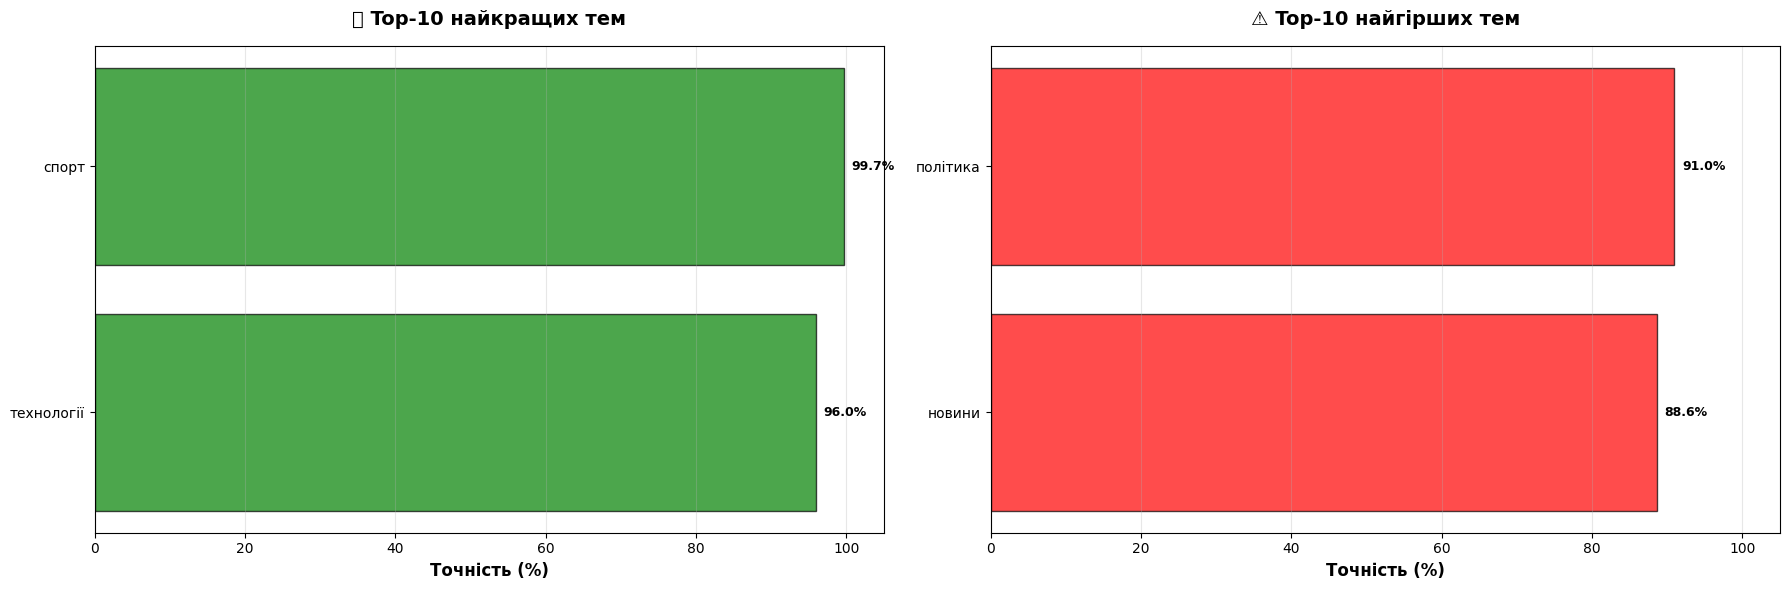

In [22]:
# 2. Top-10 найкращих і найгірших тем
print("\n📊 Top-10 тем з найкращою та найгіршою точністю...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Top-10 найкращих
top_10_best = df_accuracies.head(2)
bars1 = ax1.barh(range(len(top_10_best)), top_10_best['Accuracy'], color='green', alpha=0.7, edgecolor='black')
ax1.set_yticks(range(len(top_10_best)))
ax1.set_yticklabels(top_10_best['Theme'], fontsize=10)
ax1.set_xlabel('Точність (%)', fontsize=12, weight='bold')
ax1.set_title('🏆 Top-10 найкращих тем', fontsize=14, weight='bold', pad=15)
ax1.set_xlim(0, 105)
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

for i, (idx, row) in enumerate(top_10_best.iterrows()):
    ax1.text(row['Accuracy'] + 1, i, f"{row['Accuracy']:.1f}%", 
             va='center', fontsize=9, weight='bold')

# Top-10 найгірших
top_10_worst = df_accuracies.tail(2)
bars2 = ax2.barh(range(len(top_10_worst)), top_10_worst['Accuracy'], color='red', alpha=0.7, edgecolor='black')
ax2.set_yticks(range(len(top_10_worst)))
ax2.set_yticklabels(top_10_worst['Theme'], fontsize=10)
ax2.set_xlabel('Точність (%)', fontsize=12, weight='bold')
ax2.set_title('⚠️ Top-10 найгірших тем', fontsize=14, weight='bold', pad=15)
ax2.set_xlim(0, 105)
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

for i, (idx, row) in enumerate(top_10_worst.iterrows()):
    ax2.text(row['Accuracy'] + 1, i, f"{row['Accuracy']:.1f}%", 
             va='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()


📊 Розподіл кількості тестових зразків по темах...


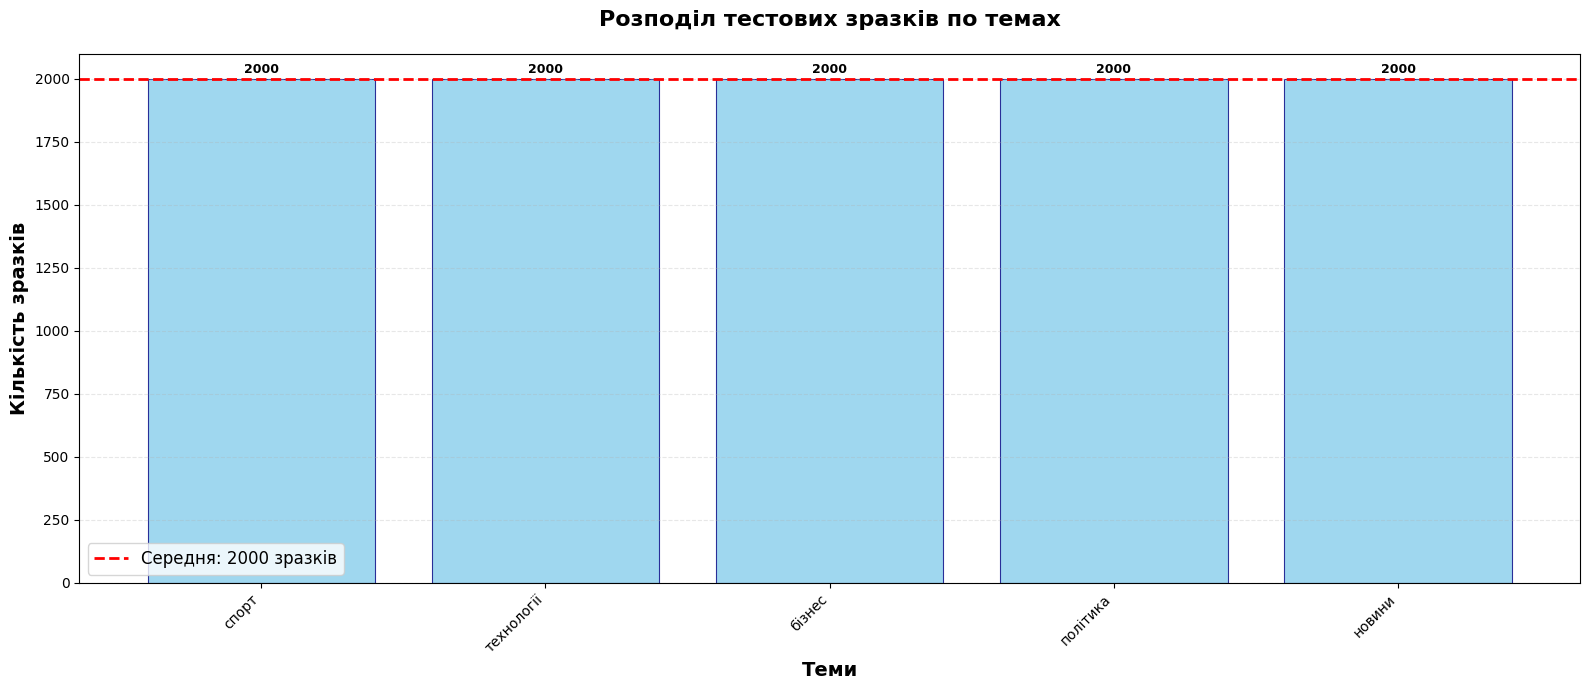

✅ Загальна кількість тестових зразків: 10000
✅ Середня кількість зразків на тему: 2000
✅ Min: 2000 | Max: 2000


In [23]:
# 3. Розподіл кількості зразків по темах
print("\n📊 Розподіл кількості тестових зразків по темах...")

df_samples = df_accuracies.sort_values('Total', ascending=False)

plt.figure(figsize=(16, 7))
bars = plt.bar(range(len(df_samples)), df_samples['Total'], 
               color='skyblue', edgecolor='navy', linewidth=0.8, alpha=0.8)
plt.xlabel('Теми', fontsize=14, weight='bold')
plt.ylabel('Кількість зразків', fontsize=14, weight='bold')
plt.title('Розподіл тестових зразків по темах', fontsize=16, weight='bold', pad=20)
plt.xticks(range(len(df_samples)), df_samples['Theme'], rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Середня лінія
avg_samples = df_samples['Total'].mean()
plt.axhline(y=avg_samples, color='red', linestyle='--', linewidth=2, 
            label=f'Середня: {avg_samples:.0f} зразків')
plt.legend(fontsize=12)

# Додаємо значення на найвищі стовпчики (топ-5)
for i in range(min(5, len(df_samples))):
    plt.text(i, df_samples.iloc[i]['Total'] + 10, 
             f"{df_samples.iloc[i]['Total']}", 
             ha='center', va='bottom', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

print(f"✅ Загальна кількість тестових зразків: {df_samples['Total'].sum()}")
print(f"✅ Середня кількість зразків на тему: {avg_samples:.0f}")
print(f"✅ Min: {df_samples['Total'].min()} | Max: {df_samples['Total'].max()}")


📊 Аналіз найбільших помилок між темами...


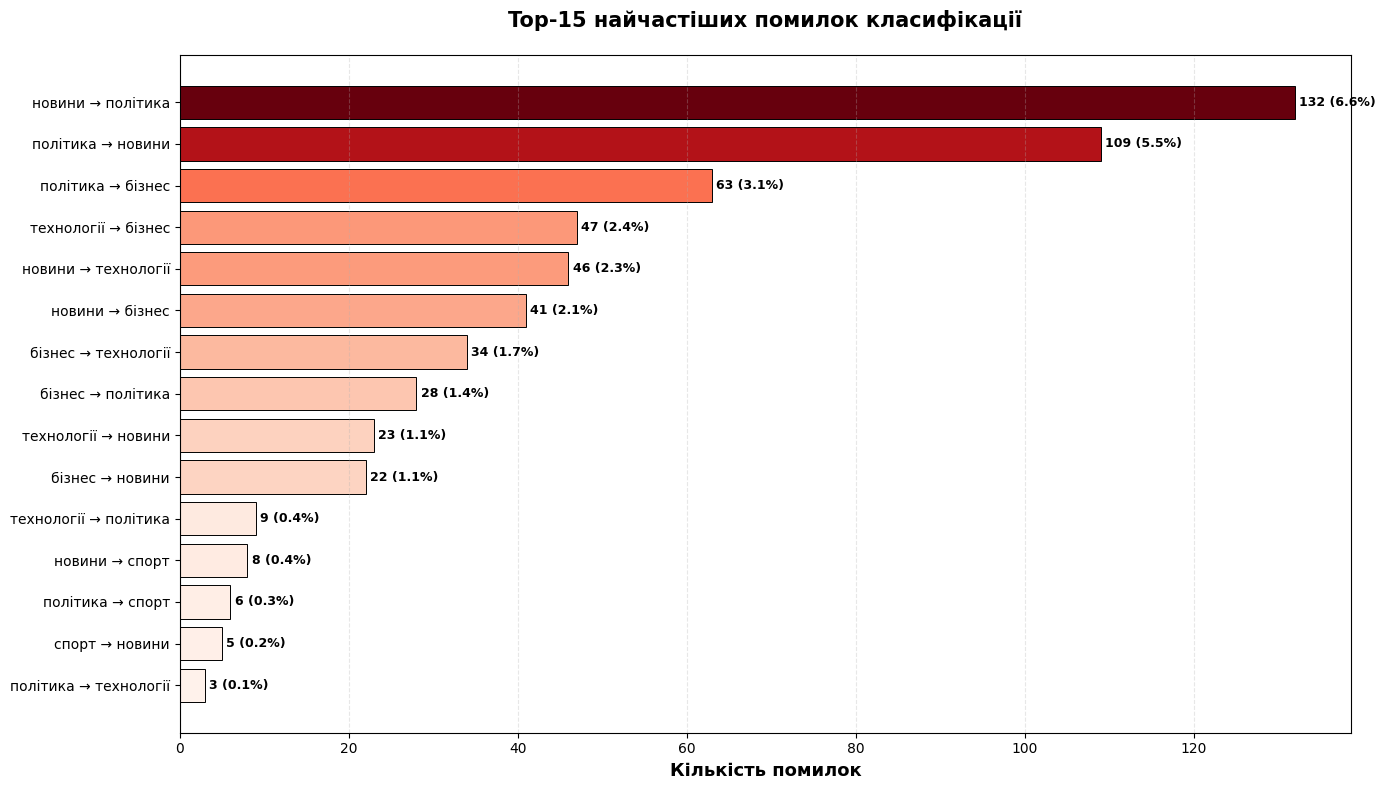


🔍 Топ-5 найчастіших помилок:
1. 'новини' плутається з 'політика': 132 разів (6.6%)
2. 'політика' плутається з 'новини': 109 разів (5.5%)
3. 'політика' плутається з 'бізнес': 63 разів (3.1%)
4. 'технології' плутається з 'бізнес': 47 разів (2.4%)
5. 'новини' плутається з 'технології': 46 разів (2.3%)


In [24]:
# 4. Heatmap найбільших помилок між темами
print("\n📊 Аналіз найбільших помилок між темами...")

# Нормалізована confusion matrix (показує % помилок)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Знаходимо топ-10 найбільших помилок (крім діагоналі)
errors = []
for i in range(len(unique_classes)):
    for j in range(len(unique_classes)):
        if i != j and cm[i][j] > 0:  # Виключаємо діагональ і нульові помилки
            errors.append({
                'True': unique_classes[i],
                'Predicted': unique_classes[j],
                'Count': cm[i][j],
                'Percentage': cm_normalized[i][j] * 100
            })

df_errors = pd.DataFrame(errors).sort_values('Count', ascending=False).head(15)

plt.figure(figsize=(14, 8))
y_pos = range(len(df_errors))
colors = plt.cm.Reds(df_errors['Count'] / df_errors['Count'].max())

bars = plt.barh(y_pos, df_errors['Count'], color=colors, edgecolor='black', linewidth=0.7)
plt.yticks(y_pos, [f"{row['True']} → {row['Predicted']}" for _, row in df_errors.iterrows()], fontsize=10)
plt.xlabel('Кількість помилок', fontsize=13, weight='bold')
plt.title('Top-15 найчастіших помилок класифікації', fontsize=15, weight='bold', pad=20)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.gca().invert_yaxis()

# Додаємо значення
for i, (idx, row) in enumerate(df_errors.iterrows()):
    plt.text(row['Count'] + 0.5, i, f"{row['Count']} ({row['Percentage']:.1f}%)", 
             va='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

print("\n🔍 Топ-5 найчастіших помилок:")
for i, (idx, row) in enumerate(df_errors.head(5).iterrows(), 1):
    print(f"{i}. '{row['True']}' плутається з '{row['Predicted']}': {row['Count']} разів ({row['Percentage']:.1f}%)")


📊 ПІДСУМКОВА СТАТИСТИКА МОДЕЛІ КЛАСИФІКАЦІЇ ПО ТЕМАХ
                          Метрика       Значення
     Загальна точність (Accuracy)         94.18%
                    Кількість тем              5
          Всього тестових зразків          10000
         Середня точність по темі         94.18%
                    Найкраща тема  спорт (99.7%)
                    Найгірша тема новини (88.6%)
 Кількість правильних передбачень           9418
                Кількість помилок            582
Середня кількість зразків на тему           2000


C:\Users\igrew\AppData\Local\Temp\ipykernel_3052\4278250568.py:86: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\igrew\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


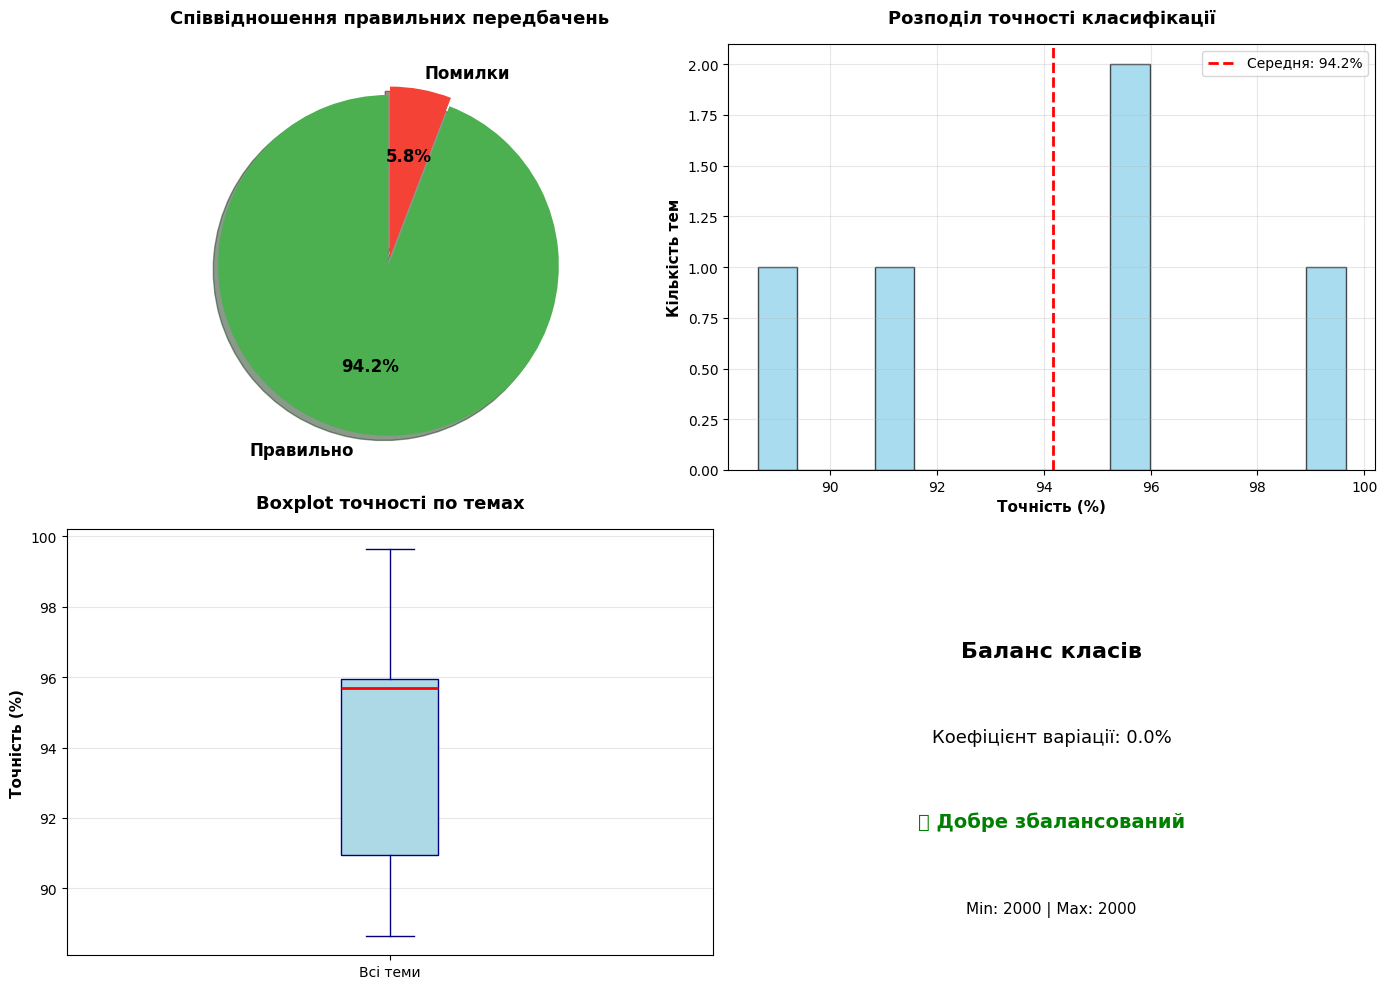


✅ Всі графіки створено успішно!


In [25]:
# 5. Підсумкова статистика у вигляді таблиці
print("\n" + "="*80)
print("📊 ПІДСУМКОВА СТАТИСТИКА МОДЕЛІ КЛАСИФІКАЦІЇ ПО ТЕМАХ")
print("="*80)

summary_data = {
    'Метрика': [
        'Загальна точність (Accuracy)',
        'Кількість тем',
        'Всього тестових зразків',
        'Середня точність по темі',
        'Найкраща тема',
        'Найгірша тема',
        'Кількість правильних передбачень',
        'Кількість помилок',
        'Середня кількість зразків на тему'
    ],
    'Значення': [
        f"{accuracy_test * 100:.2f}%",
        len(unique_classes),
        len(Y_test),
        f"{df_accuracies['Accuracy'].mean():.2f}%",
        f"{df_accuracies.iloc[0]['Theme']} ({df_accuracies.iloc[0]['Accuracy']:.1f}%)",
        f"{df_accuracies.iloc[-1]['Theme']} ({df_accuracies.iloc[-1]['Accuracy']:.1f}%)",
        np.trace(cm),
        cm.sum() - np.trace(cm),
        f"{df_samples['Total'].mean():.0f}"
    ]
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print("="*80)

# Візуалізація підсумкової статистики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Pie chart правильних vs помилкових
correct = np.trace(cm)
incorrect = cm.sum() - correct
axes[0, 0].pie([correct, incorrect], labels=['Правильно', 'Помилки'], 
               autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
               explode=(0.05, 0), shadow=True, startangle=90,
               textprops={'fontsize': 12, 'weight': 'bold'})
axes[0, 0].set_title('Співвідношення правильних передбачень', fontsize=13, weight='bold', pad=15)

# График 2: Розподіл точності по темах (гістограма)
axes[0, 1].hist(df_accuracies['Accuracy'], bins=15, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df_accuracies['Accuracy'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Середня: {df_accuracies["Accuracy"].mean():.1f}%')
axes[0, 1].set_xlabel('Точність (%)', fontsize=11, weight='bold')
axes[0, 1].set_ylabel('Кількість тем', fontsize=11, weight='bold')
axes[0, 1].set_title('Розподіл точності класифікації', fontsize=13, weight='bold', pad=15)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# График 3: Boxplot точності по темах
axes[1, 0].boxplot(df_accuracies['Accuracy'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='navy'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='navy'),
                   capprops=dict(color='navy'))
axes[1, 0].set_ylabel('Точність (%)', fontsize=11, weight='bold')
axes[1, 0].set_title('Boxplot точності по темах', fontsize=13, weight='bold', pad=15)
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_xticklabels(['Всі теми'])

# График 4: Співвідношення балансу класів
balance = df_samples['Total'].std() / df_samples['Total'].mean() * 100
axes[1, 1].text(0.5, 0.7, f"Баланс класів", ha='center', fontsize=16, weight='bold')
axes[1, 1].text(0.5, 0.5, f"Коефіцієнт варіації: {balance:.1f}%", ha='center', fontsize=13)
if balance < 20:
    balance_text = "✅ Добре збалансований"
    color = 'green'
elif balance < 40:
    balance_text = "⚠️ Помірно збалансований"
    color = 'orange'
else:
    balance_text = "❌ Незбалансований"
    color = 'red'
axes[1, 1].text(0.5, 0.3, balance_text, ha='center', fontsize=14, weight='bold', color=color)
axes[1, 1].text(0.5, 0.1, f"Min: {df_samples['Total'].min()} | Max: {df_samples['Total'].max()}", 
                ha='center', fontsize=11)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Всі графіки створено успішно!")

In [29]:
sentence = "Своя праска ближча до тіла. Українські бренди завойовують нижній ціновий сегмент побутової техніки , Національні бренди побутової техніки та електроніки не тільки нарощують продажі в Україні, але вийшли вже й на зовнішні ринки, пише журнал НВ  Ужовтні 2018 року на вітчизняному ТБ крутили ролик про смішного чолов’ягу, зацикленого на придбанні нового телевізора. Замість компліментів дружині він торочив про діагоналі, кумедна собачка викликала у нього думки про процесор, а занурюючись у теплу ванну, він млосним голосом вимовляв назву операційної системи.Ролик, призначений для національних споживачів, присвятили цифровому телевізору марки KIVI. Під такою екзотичною і дещо фруктовою назвою продає свої товари вітчизняна компанія Kindle Vision, що розміщує замовлення у Китаї.Справи у цього виробника йдуть відмінно: бренд став гравцем № 1 серед українських брендів. Такі дані НВ озвучили в прес-службі одного з найбільших продавців побутової техніки й електроніки у країні.Аби досягти такого помітного успіху, KIVI знадобилося всього два роки — бренд з’явився у 2016-му. Євген Руденко, співзасновник KIVI, пояснив НВ: плануючи випуск своїх пристроїв, його компанія орієнтувалася на дві технології, які розвивають ринок телевізорів. Перша — це смарт-ТВ, тобто можливість виходу в інтернет. Друга — HD-роздільна здатність екрану: чим вона вища, тим емоційніша картинка. «Ми подивилися, що в цьому сегменті крім LG і Samsung — а у них дорогий продукт — на ринку нічого немає», — розповів Руденко.Телевізори KIVI — далеко не єдиний приклад. У країні успішно продається ще з десяток місцевих брендів, які переховуються під «імпортними» назвами і, як правило, розміщують замовлення на виробництво у Китаї. Так, велику і дрібну побутову техніку роблять Mirta, Saturn і Prime, витяжки — Pyramida, електро- і газові плити — Greta, обігрівачі — Atlantic і Stinex, вентилятори — Vents.Українці до сегменту високотехнологічних виробів зі своїми марками найчастіше не лізуть, вважаючи за краще насичувати національний ринок побутовими приладами. Основний козир такої продукції — демократична ціна.І він грає: продажі українських марок незмінно зростають, говорять представники торгових мереж. Наприклад, у відділі побутової техніки мережі Епіцентр К сьогодні кожен п’ятий проданий товар припадає на продукцію вітчизняних брендів.Олександр Величко з Епіцентру К розповідає: цьогоріч мережа продала майже на 11% більше українських товарів, ніж у 2018-му. А в деяких категоріях місцеві бренди вже стали № 1. Так, наприклад, сталося у сегменті кліматичної техніки, де панує компанія Vents, зареєстрована в Боярці під Києвом і там таки має виробництво.У Фокстроті — а це мережа-лідер у сфері торгівлі побутовою технікою й електронікою у країні — частка вітчизняної продукції становить уже 10%. «Ми спостерігаємо тенденцію до збільшення попиту і прогнозуємо до кінця року надбавку до 12%», — каже Юрій Поліщук, комерційний директор Фокстроту.Торгові мережі також продають техніку під власними марками, замовляючи товар у Китаї. У Фокстроті це телевізори Bravis і побутові прилади Delfa. Подібна продукція надходить до покупця без посередників і дистриб’юторів, що дозволяє тримати невисоку ціну. «Це приваблює споживачів і утримує стабільне зростання попиту на 1−2% на рік», — зазначає Поліщук. UA замість RU П ідприємець Артем Лукашев до кризи 2008 року працював на позиції топ-менеджера в українському представництві корейської компанії LG. У період економічної нестабільності він зауважив, що співвітчизники перестали гнатися за гучними іменами і почали вибирати пристрої за їх функціональністю. «Ми з партнером [який також працював у LG] побачили в цьому можливість», — згадує Лукашев. Пара бізнесменів націлилася на нижній ціновий сегмент побутової техніки, інвестувавши у виробництво $350 тис. Так з’явилася компанія Mirta, в асортименті якої зараз є все що завгодно: чайники, духовки, плити, мультиварки, кухонні комбайни та багато іншого.Те, що у Лукашева настільки помітно зріс асортимент, виглядає цілком логічно, адже і ринок збільшується. У першому півріччі 2019 року продажі великої побутової техніки, за даними дослідницької компанії GfK, зросли на 17%, дрібної — на 18%.Стимулюють цей процес, за словами співзасновника Mirta, прискорення продажів недорогих продуктів у всіх сегментах. А саме там керують балом національні бренди.Так, якщо вітчизняний електрочайник Saturn обійдеться покупцеві у суму від 200 грн, а Mirta або Magio — від 300 грн, то ціна на аналогічний товар світових брендів — Gorenje, Philips або Bosch — стартує від 500 грн. Окрім того, функціоналом всі ці чайники не відрізняються. Тому покупець, дисциплінований низкою криз і падінням курсу гривні, все частіше віддає перевагу «своїм».До того ж іноземці, які виробляють продукцію верхнього цінового сегмента — так званого А-класу, — ще й знизили в останні роки свою маркетингову активність. І в цьому теж присутня логіка: через девальвацію національної валюти гривневі ціни на імпортні товари злетіли і споживачі логічно відвернулися від дорогих продуктів.У підсумку, наприклад, телевізори марок Philips, Panasonic, Sharp і Toshiba з ринку не пішли, і в продажу вони є. Але, як зазначає Поліщук із Фокстроту, ці транснаціональні бренди перестали вкладати кошти в Україну — робити промо, оголошувати цінові акції, хоча раніше активно цим займалися.Іноземці «пригальмували», і цим одразу скористався KIVI зі своїми смарт-телевізорами. Ціни на них стартують із 6,2 тис. грн для панелей із діагоналлю 40 дюймів. У Philips і Sharp вартість аналогічного продукту починається із 7 тис. грн, а у Panasonic — із 11 тис. грн.Зміцнити позиції недорогим українським брендам допоміг бойкот українських споживачів проти вироблених у Росії товарів.Багато глобальних компаній, які випускали на своїх російських заводах продукцію для України, після 2014-го були змушені змінювати схему постачання. «У період, коли глобальні бренди перерозподіляли постачання із Росії на заводи в інших країнах, були перебої», — розповідає Поліщук. І тимчасово звільнені ніші атакували українські марки.Імідж країни-агресора негативно відбився і на продажах в Україні колись популярних російських бюджетних брендів побутової техніки — Vitek, Scarlett, Polaris. «Відійшли росіяни, які відкушували істотну частину ринку, — розповідає Лукашев із Mirta. — Їх ще можна зустріти у наших магазинах, але продаються вони не дуже добре проти того, що було раніше».А от продажі Mirta зростають: за словами Лукашева, останні кілька років надбавка становила 10−15% річних. А за підсумками 2019 року він очікує плюс 30%. Особливості національної техніки Місцеві гравці беруть покупця за гаманець не тільки своєю доступністю, а й умінням тонше підлаштуватися під локальні тренди.Наприклад, у 2013-му в Україні увійшов у моду яскравий дизайн інтер'єрів. І компанія Pyramida випустила на ринок витяжки червоного кольору. «Спочатку вони [споживачі] могли купити товар такої кольорової гами тільки у нас», — розповідає Костянтин Михайленко, комерційний директор Pyramida.Український бренд, за словами топ-менеджера, здатен досить швидко виводити нові товарні позиції, й цим він відрізняється від світових виробників, у яких кожне рішення проходить багато етапів погоджень. Тому Pyramida, як зазначив Михайленко, для запуску нової моделі — від моменту прийняття рішення до появи у роздрібі — потрібно п’ять-шість місяців, а транснаціональним брендам — від року. Внаслідок зі 120 тис. проданих за рік витяжок вітчизняна компанія завоювала третину національного ринку.У Mirta теж є схожа історія: у 2011-му фірма зважилася обладнати свої кухонні комбайни насадками для дерунів. «Ми були першими, хто почав це робити на нашому ринку. Потім і решта підтяглися», — каже Лукашев.Ще одне вдале рішення — прес для томатів, яким Mirta стала комплектувати свої м’ясорубки. Тепер 90% товарів цієї категорії на ринку оснащують подібною насадкою. Замінити Китай Більшу частину техніки вітчизняних брендів виробляють аж ніяк не в Україні, а в Китаї та інших країнах Південно-Східної Азії. Там є високотехнологічне виробництво у великих обсягах, говорить Поліщук з Фокстроту, що дає можливість отримувати конкурентний продукт за доступною ціною.Втім, деякі свої потужності українці стали розміщувати вже і на батьківщині. Так, компанія KTD Group, що випускає товари під маркою Saturn, спочатку всю свою продукцію замовляла в Піднебесній. Але з часом, як розповів засновник KTD Group Олександр Громико, відкрила завод у Каневі, де тепер робить частину своєї продукції. А чотири роки тому Громико купив ще й проммайданчик у Черкасах, на якому планує виробляти холодильники.Своє виробництво в Україні та у компанії Greta, яка збирає на Донбасі (у Дружківці) кухонні плити. За словами Володимира Нещеретова, заступника гендиректора Greta зі збуту, вони б і раді повністю замкнути виробництво на батьківщині, але для цього потрібні суміжні виробництва, яких у країні немає. Тому зараз до 80% комплектування Greta закуповує за кордоном.Водночас українці примудрилися не тільки завоювати свій ринок, але і вийти за межі країни. Так, із 200 тис. плит, які Greta виробляє за рік, близько 70 тис. піде — за підсумками 2019-го — у країни Балтії, Польщу, Румунію, Чехію та Угорщину. Крім того, експорт зростає: у 2016-му Дружківська компанія продавала на зовнішні ринки лише 26 тис. плит, а торік — 55 тис.Вивозить із країни свою продукцію і Pyramida: кожна п’ята витяжка бренду йде на ринки Білорусі, Казахстану, Молдови, Грузії, Росії, Вірменії, Азербайджану та навіть ОАЕ."

sentence = filtering(sentence)
sentence = lemmatize_text(sentence)
X = vectorizer.transform([sentence])

prediction = model_theme.predict(X)
proba = model_theme.predict_proba(X)[0] 

print(f"Категорія: {prediction[0]}")
print(f"Впевненість: {max(proba) * 100:.2f}%")
print()
print("Всі теми:")
for theme, prob in zip(model_theme.classes_, proba):
    print(f"  {theme}: {prob * 100:.2f}%")

Категорія: бізнес
Впевненість: 95.87%

Всі теми:
  бізнес: 95.87%
  новини: 0.09%
  політика: 0.05%
  спорт: 0.00%
  технології: 3.99%


In [30]:
import pickle

with open('theme_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
with open('theme_model.pkl', 'wb') as f:
    pickle.dump(model_theme, f)